# 06 · Human-on-the-loop · **Wait for input**

**Idea:** The agent realises it's missing information and **asks the human**, then continues with the answer.
Same `interrupt()` mechanism as approval — but now the human's reply is *data*, not a yes/no.

We show two styles:
* **A. Inside a node** – the graph itself asks questions (you control the flow).
* **B. As a tool** – the *LLM decides* when to ask the human (`ask_human` tool).

## How human-in-the-loop works in LangGraph (read once)

1. A node calls **`interrupt(payload)`** → the graph **pauses** and saves its state to the **checkpointer**.
2. `graph.invoke(...)` returns right away with `"__interrupt__"` holding your payload (show it to the human).
3. Later, call `graph.invoke(Command(resume=<human answer>), config)` with the **same `thread_id`**.
4. The node **re-runs from its start**, and this time `interrupt(...)` *returns the human's answer*.

⚠️ Because the node restarts, put side-effects (sending email, charging cards) **after** the `interrupt()` call, never before.
A checkpointer + `thread_id` are mandatory — that's what remembers where the graph paused.

In [1]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

## A · A node that asks questions

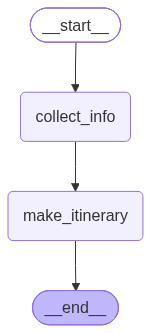

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    city: str
    days: str
    itinerary: str

def collect_info(state: State):
    # Two interrupts in ONE node: answers are matched to interrupts in order.
    # Only ask if we don't already know (makes the node safe to re-run).
    city = state.get("city") or interrupt("Which city are you visiting?")
    days = state.get("days") or interrupt("How many days will you stay?")
    return {"city": city, "days": days}

def make_itinerary(state: State):
    out = llm.invoke(f"Give a {state['days']}-day itinerary for {state['city']} in 3 short bullet points per day.")
    return {"itinerary": out.content}

builder = StateGraph(State)
builder.add_node("collect_info", collect_info)
builder.add_node("make_itinerary", make_itinerary)
builder.add_edge(START, "collect_info")
builder.add_edge("collect_info", "make_itinerary")
builder.add_edge("make_itinerary", END)
graph = builder.compile(checkpointer=InMemorySaver())

from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
cfg = {"configurable": {"thread_id": "trip-1"}}

r = graph.invoke({}, cfg)                                   # nothing known yet
print("🤖 asks:", r["__interrupt__"][0].value)

r = graph.invoke(Command(resume="Kyoto"), cfg)              # human answers question 1
print("🤖 asks:", r["__interrupt__"][0].value)

r = graph.invoke(Command(resume="2"), cfg)                  # human answers question 2 -> graph finishes
print("\n🗺️  ", r["itinerary"])

🤖 asks: Which city are you visiting?
🤖 asks: How many days will you stay?

🗺️   Here is a 2-day itinerary for Kyoto in 3 short bullet points per day:

**Day 1:**

* **Morning:** Visit the iconic Fushimi Inari Shrine, famous for its thousands of vermilion torii gates that form a tunnel up the mountain. (8:00 am - 10:00 am)
* **Lunch:** Head to Gion district, known for its traditional Japanese architecture and geisha culture. Try some traditional Kyoto cuisine, such as kaiseki or shojin-ryori, at a local restaurant. (11:00 am - 1:00 pm)
* **Afternoon:** Explore the Kinkaku-ji Temple (Golden Pavilion), a stunning example of Japanese architecture and a UNESCO World Heritage Site. (2:00 pm - 4:00 pm)

**Day 2:**

* **Morning:** Visit the Nijo Castle, a UNESCO World Heritage Site and former residence of the Tokugawa shoguns. (9:00 am - 11:00 am)
* **Lunch:** Visit the Nishiki Market, a narrow shopping street lined with over 100 food stalls and shops selling local specialties. (11:30 am - 1:0

## B · Let the LLM decide when to ask (`ask_human` tool)

This is the most flexible style: give the agent a tool whose implementation is simply `interrupt()`.
If the model can answer alone it won't call it; if it lacks info, it will.

In [5]:
from langchain.agents import create_agent
from langchain.tools import tool

@tool
def ask_human(question: str) -> str:
    """Ask the human user a clarifying question and wait for their answer."""
    return interrupt(question)          # pauses the agent; returns the human's reply on resume

@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    return f"It is 31°C and humid in {city}."      # canned data for the demo

agent = create_agent(
    llm,
    tools=[ask_human, get_weather],
    system_prompt=("You help people decide what to wear. You need the user's city. "
                   "If you do not know it, call ask_human FIRST. Then call get_weather."),
    checkpointer=InMemorySaver(),
)

In [7]:
cfg = {"configurable": {"thread_id": "wear-1"}}

r = agent.invoke({"messages": [{"role": "user", "content": "What should I wear today? include temp of the city"}]}, cfg)
print("🤖 agent asks:", r["__interrupt__"][0].value)

r = agent.invoke(Command(resume="Cuttack"), cfg)
print("\n🤖 final answer:", r["messages"][-1].content)

🤖 agent asks: What is your city?

🤖 final answer: Based on the weather in Cuttack, I would recommend wearing lightweight and breathable clothing such as cotton t-shirts and pants. The temperature is 31°C, so it's a good idea to dress in light and airy clothing to stay cool. You may also want to consider wearing a hat and sunglasses to protect yourself from the sun.
